
# Step 05 — Cell type annotation and marker discovery

**Purpose.** Assign a cell type to every cluster, with the evidence and the
confidence written down.

**Research question 1** is answered here: which major retinal cell types are
present.

## Rules this notebook enforces

1. **No invented genes.** Every marker is checked against `adata.var_names`; a
   missing marker is reported as unavailable and the panel proceeds without it.
2. **No single-marker calls.** Each assignment needs concordant evidence: a panel
   score, a data-driven marker list, and a check for conflicting markers.
3. **No forced labels.** A cluster whose evidence is ambiguous is annotated
   `Unresolved` (or `Candidate X`) and keeps that label in every figure. An honest
   "Unresolved" is defensible at a viva; a confident wrong label is not.
4. **Identity ≠ activation.** `pcna`/`mki67` say a cell is cycling, `EGFP` says a
   reporter is active. Neither is an identity marker. A cluster is Müller glia
   because of `rlbp1a`/`glula`/`slc1a3b`, not because it is EGFP-positive.

In [1]:
import sys
from pathlib import Path

# Make the repository root importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "scripts").exists(), (
    f"Cannot locate the repository root from {Path.cwd()}. "
    "Launch JupyterLab from the repository root."
)
sys.path.insert(0, str(REPO_ROOT))

from scripts import config as cfg
from scripts import io_utils, qc, preprocessing, clustering, annotation, egfp_analysis, plotting

cfg.ensure_directories()
plotting.set_style()
SEED = io_utils.set_seeds()
print(f"Repository root: {REPO_ROOT}")
print(f"Random seed: {SEED}")

Repository root: D:\retina\project1_zebrafish_retina
Random seed: 0


In [2]:
import pandas as pd
adata = io_utils.load_checkpoint("clustered")

Loaded 'clustered': 15893 cells x 2000 genes


In [3]:
print(f".X:    {adata.n_vars} genes  (scaled HVGs, for clustering)")
print(f".raw:  {adata.raw.n_vars} genes  (log-normalised, for DE and markers)")

.X:    2000 genes  (scaled HVGs, for clustering)
.raw:  22813 genes  (log-normalised, for DE and markers)



## 1. Data-driven markers per cluster

Wilcoxon rank-sum on the **log-normalised** values (via `.raw`), not on the scaled
matrix.

In [4]:
adata = annotation.rank_markers(adata)
marker_df = annotation.markers_to_dataframe(adata)
io_utils.save_table(marker_df, "marker_genes.csv")
display(annotation.top_markers_per_cluster(marker_df, n=10))

Ranked markers for 'leiden_res_0.6' with wilcoxon on .raw (22813 genes).
Wrote tables\marker_genes.csv  (1000 rows)


,cluster,top_10_genes
0,0,"pde6b, pde6a, map1ab, gnb1b, mbnl2, si:ch211-1..."
1,1,"si:dkey-14d8.22, si:ch211-98n17.5, hlx1, ap5m1..."
2,2,"rho, pde6gb, ppdpfa, gngt1, rom1b, gnat1, rom1..."
3,3,"syt1a, stx1b, pclob, elavl3, tkta, gpm6aa, sna..."
4,4,"mt-co2, mt-atp6, rho, mt-co1, mt-nd1, ppdpfa, ..."
5,5,"hbba1-1, hbaa1, hbba1, si:ch211-5k11.8, creg1,..."
6,6,"fabp7a, eef1a1l1, hmgn2, rplp0, rplp1, hsp90ab..."
7,7,"glula, nfasca, slc1a2b, cahz, gpm6aa, pleca, p..."
8,8,"tnr, SLC4A5, sept15, pcdh8, pcbp3, SLC4A5-1, s..."
9,9,"gnb3b, gnat2, pde6ha, rcvrn2, es1, pde6c, gngt..."



## 2. Canonical panel scores

Two panels: the one supplied by the project guide, and a supplementary set drawn
from Bise et al. for the cell types the guide's panel does not cover (horizontal
cells, oligodendrocytes, erythrocytes, pericytes, RPE).

In [5]:
print("=== Guide panel ===")
adata = annotation.score_panels(adata, cfg.MARKERS_GUIDE, prefix="score")
print("\n=== Supplementary panel (Bise et al.) ===")
adata = annotation.score_panels(adata, cfg.MARKERS_PAPER, prefix="paper")

=== Guide panel ===
[Muller glia (resting)] not in this dataset (1): ['slc1a3b']
[Activated MG / progenitor] not in this dataset (2): ['pcna', 'her4.1']
[Rod photoreceptors] not in this dataset (1): ['gnat1']
[Bipolar cells] not in this dataset (2): ['vsx2', 'islet1']
[Retinal ganglion cells] not in this dataset (1): ['isl2b']

=== Supplementary panel (Bise et al.) ===
[Muller glia] not in this dataset (1): ['glulb']
[Rods (mature-like)] not in this dataset (5): ['rhol', 'guca1b', 'sagb', 'gnb1a', 'rcvrna']
[Rods (immature-like)] not in this dataset (4): ['pde6ga', 'meig1', 'rom1b', 'gngt1']
[Cones (UV)] not in this dataset (1): ['tbx2a']
[Bipolar cells] not in this dataset (1): ['prkca']
[Pericytes] not in this dataset (1): ['myl9a']
[RPE] not in this dataset (1): ['bhlhe40']


In [6]:
score_matrix = annotation.panel_score_matrix(adata, prefix="score")
display(score_matrix.style.background_gradient(axis=1, cmap="RdBu_r"))

suggestions = annotation.best_and_runner_up(score_matrix)
display(suggestions)

,Muller glia (resting),Activated MG progenitor,Rod photoreceptors,Cone photoreceptors,Bipolar cells,Amacrine cells,Retinal ganglion cells,Microglia immune
leiden_res_0.6,,,,,,,,
0,-0.328000,-0.035000,2.910000,-0.009000,-0.196000,-0.347000,-0.044000,-0.055000
1,-0.405000,0.081000,2.489000,1.934000,-0.187000,-0.486000,-0.111000,-0.198000
2,-0.631000,-0.005000,3.492000,-0.019000,-0.056000,-0.307000,-0.012000,-0.012000
3,0.143000,-0.096000,1.044000,-0.267000,-0.130000,0.836000,-0.029000,-0.150000
4,-0.488000,0.009000,3.378000,0.002000,-0.029000,-0.271000,0.009000,0.004000
5,-0.391000,-0.026000,1.974000,0.021000,-0.086000,-0.276000,-0.023000,-0.045000
6,0.648000,0.316000,1.762000,-0.081000,-0.025000,-0.273000,0.128000,-0.097000
7,1.765000,-0.080000,0.980000,-0.429000,-0.016000,0.242000,0.462000,-0.221000
8,-0.256000,-0.095000,1.274000,0.094000,-0.202000,1.190000,-0.083000,-0.144000


,cluster,best_panel,best_score,runner_up_panel,runner_up_score,margin,suggested_confidence
0,0,Rod photoreceptors,2.910,Cone photoreceptors,-0.009,2.919,high
1,1,Rod photoreceptors,2.489,Cone photoreceptors,1.934,0.555,high
2,2,Rod photoreceptors,3.492,Activated MG progenitor,-0.005,3.497,high
3,3,Rod photoreceptors,1.044,Amacrine cells,0.836,0.208,high
4,4,Rod photoreceptors,3.378,Activated MG progenitor,0.009,3.369,high
5,5,Rod photoreceptors,1.974,Cone photoreceptors,0.021,1.953,high
6,6,Rod photoreceptors,1.762,Muller glia (resting),0.648,1.114,high
7,7,Muller glia (resting),1.765,Rod photoreceptors,0.980,0.785,high
8,8,Rod photoreceptors,1.274,Amacrine cells,1.190,0.084,medium
9,9,Rod photoreceptors,2.489,Cone photoreceptors,1.190,1.299,high


In [7]:
paper_matrix = annotation.panel_score_matrix(adata, prefix="paper")
display(paper_matrix.style.background_gradient(axis=1, cmap="RdBu_r"))

,Muller glia,Rods (mature-like),Rods (immature-like),Cones (UV),Cones (non-UV),Horizontal cells,Bipolar cells,Oligodendrocytes,Erythrocytes,Pericytes,Microglia,RPE
leiden_res_0.6,,,,,,,,,,,,
0,-0.194000,4.021000,3.117000,-0.103000,0.098000,-0.040000,-0.301000,-0.033000,-0.053000,-0.047000,-0.060000,-0.129000
1,-0.445000,2.730000,2.205000,1.307000,1.856000,-0.004000,-0.198000,-0.197000,-0.265000,-0.097000,-0.710000,-0.567000
2,-0.152000,4.786000,4.422000,-0.050000,0.144000,-0.013000,-0.248000,-0.002000,0.008000,-0.015000,-0.016000,0.048000
3,-0.183000,0.791000,0.785000,-0.221000,-0.191000,-0.089000,-0.138000,-0.058000,-0.155000,-0.101000,-0.331000,-0.312000
4,-0.099000,4.397000,4.166000,-0.032000,0.161000,-0.011000,-0.230000,0.032000,0.009000,-0.001000,0.040000,0.077000
5,-0.048000,1.429000,1.803000,0.000000,0.221000,-0.081000,-0.225000,-0.012000,5.707000,-0.124000,0.027000,0.109000
6,0.383000,1.846000,1.370000,-0.066000,0.045000,-0.046000,0.117000,0.114000,-0.107000,0.088000,-0.291000,-0.207000
7,1.021000,0.974000,0.676000,-0.319000,-0.362000,-0.122000,0.249000,-0.085000,-0.255000,0.884000,-0.489000,-0.452000
8,-0.245000,1.277000,1.178000,0.002000,0.109000,1.029000,-0.172000,-0.058000,-0.125000,-0.020000,-0.376000,-0.316000



### How to read the suggestion table

`suggested_confidence` is arithmetic, not judgement: it reflects the margin
between the best and second-best panel score. Use it to decide where to look
harder, then set the confidence yourself in the annotation dictionary below.

A small margin usually means one of three things, and they need different
responses:

- **Two related types** (e.g. rod vs cone) — resolve with individual marker
  expression, not the panel score.
- **A doublet cluster** — high on two unrelated panels at once; check whether it
  also has elevated counts and gene numbers.
- **A state rather than a type** (e.g. activated MG) — high on an identity panel
  *and* on activation markers. Annotate the identity, and record the state
  separately.

In [8]:
# Individual marker expression per cluster, for resolving the ambiguous ones.
all_guide_genes = [g for genes in cfg.MARKERS_GUIDE.values() for g in genes]
expr = annotation.mean_marker_expression(adata, all_guide_genes)
display(expr.style.background_gradient(axis=0, cmap="viridis"))

[mean_marker_expression] not in this dataset (7): ['slc1a3b', 'pcna', 'her4.1', 'gnat1', 'vsx2', 'islet1', 'isl2b']


,rlbp1a,glula,mki67,ascl1a,rho,nr2e3,opn1sw1,opn1sw2,opn1mw1,opn1lw1,vsx1,gad1b,gad2,tfap2a,rbpms2b,pou4f1,mpeg1.1,coro1a,cxcr4b
leiden_res_0.6,,,,,,,,,,,,,,,,,,,
0,0.219000,0.659000,0.047000,0.015000,6.278000,0.311000,0.564000,0.604000,0.100000,0.236000,0.031000,0.114000,0.137000,0.038000,0.059000,0.007000,0.009000,0.021000,0.004000
1,1.000000,1.530000,0.460000,0.084000,6.034000,0.900000,3.999000,3.524000,1.823000,2.300000,0.441000,0.884000,0.600000,0.330000,0.214000,0.020000,0.005000,0.017000,0.040000
2,0.122000,0.426000,0.030000,0.010000,7.533000,0.148000,0.498000,0.533000,0.065000,0.219000,0.041000,0.075000,0.075000,0.041000,0.032000,0.002000,0.021000,0.023000,0.003000
3,0.590000,1.524000,0.068000,0.022000,3.207000,0.093000,0.523000,0.508000,0.115000,0.207000,0.287000,1.185000,1.889000,1.451000,0.231000,0.028000,0.021000,0.017000,0.011000
4,0.237000,0.665000,0.054000,0.013000,7.326000,0.142000,0.523000,0.595000,0.074000,0.238000,0.064000,0.112000,0.119000,0.080000,0.074000,0.002000,0.036000,0.043000,0.015000
5,0.135000,0.500000,0.008000,0.015000,4.543000,0.076000,0.583000,0.599000,0.090000,0.152000,0.013000,0.055000,0.115000,0.075000,0.015000,0.000000,0.028000,0.014000,0.036000
6,1.386000,2.118000,0.622000,0.223000,4.313000,0.394000,0.851000,0.733000,0.150000,0.307000,0.294000,0.382000,0.446000,0.297000,0.445000,0.031000,0.021000,0.019000,0.019000
7,2.328000,3.541000,0.167000,0.089000,3.286000,0.198000,0.539000,0.433000,0.086000,0.271000,0.536000,1.081000,1.178000,0.978000,1.288000,0.036000,0.012000,0.019000,0.019000
8,0.474000,0.964000,0.044000,0.021000,3.632000,0.081000,0.981000,0.932000,0.237000,0.554000,0.199000,2.252000,2.132000,1.153000,0.131000,0.003000,0.007000,0.009000,0.001000



## Figure 3A/B — marker dotplot and heatmap

Saved figure_03_marker_dotplot -> figures\figure_03_markers/ (png, pdf)
Saved figure_03_marker_heatmap -> figures\figure_03_markers/ (png, pdf)


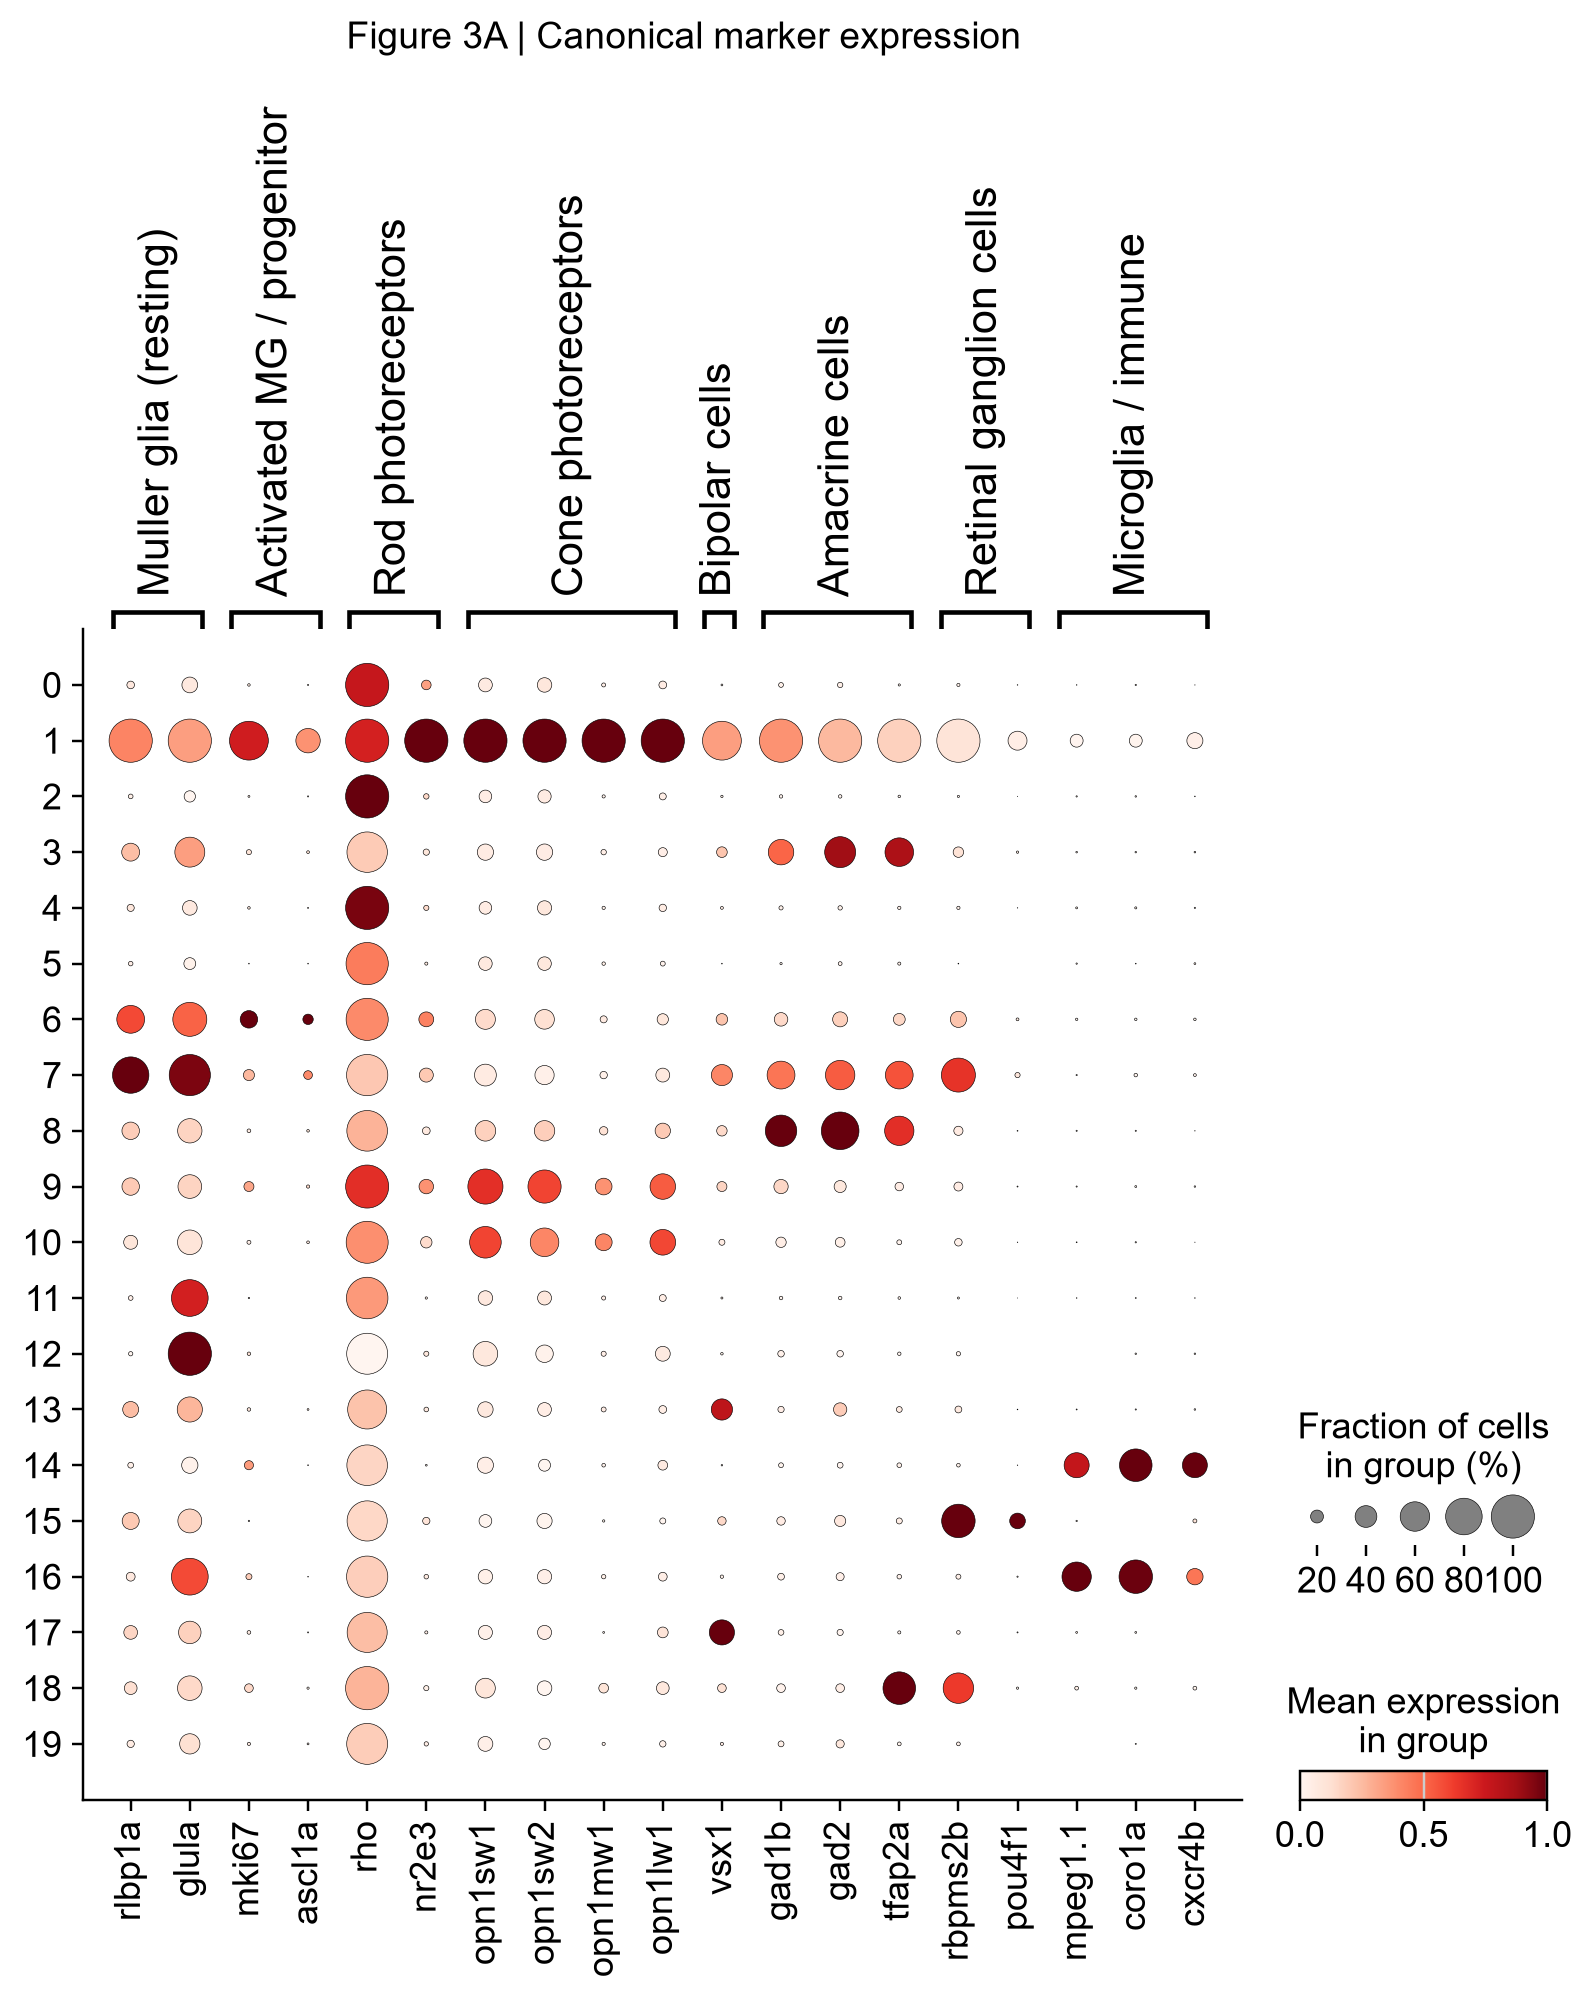

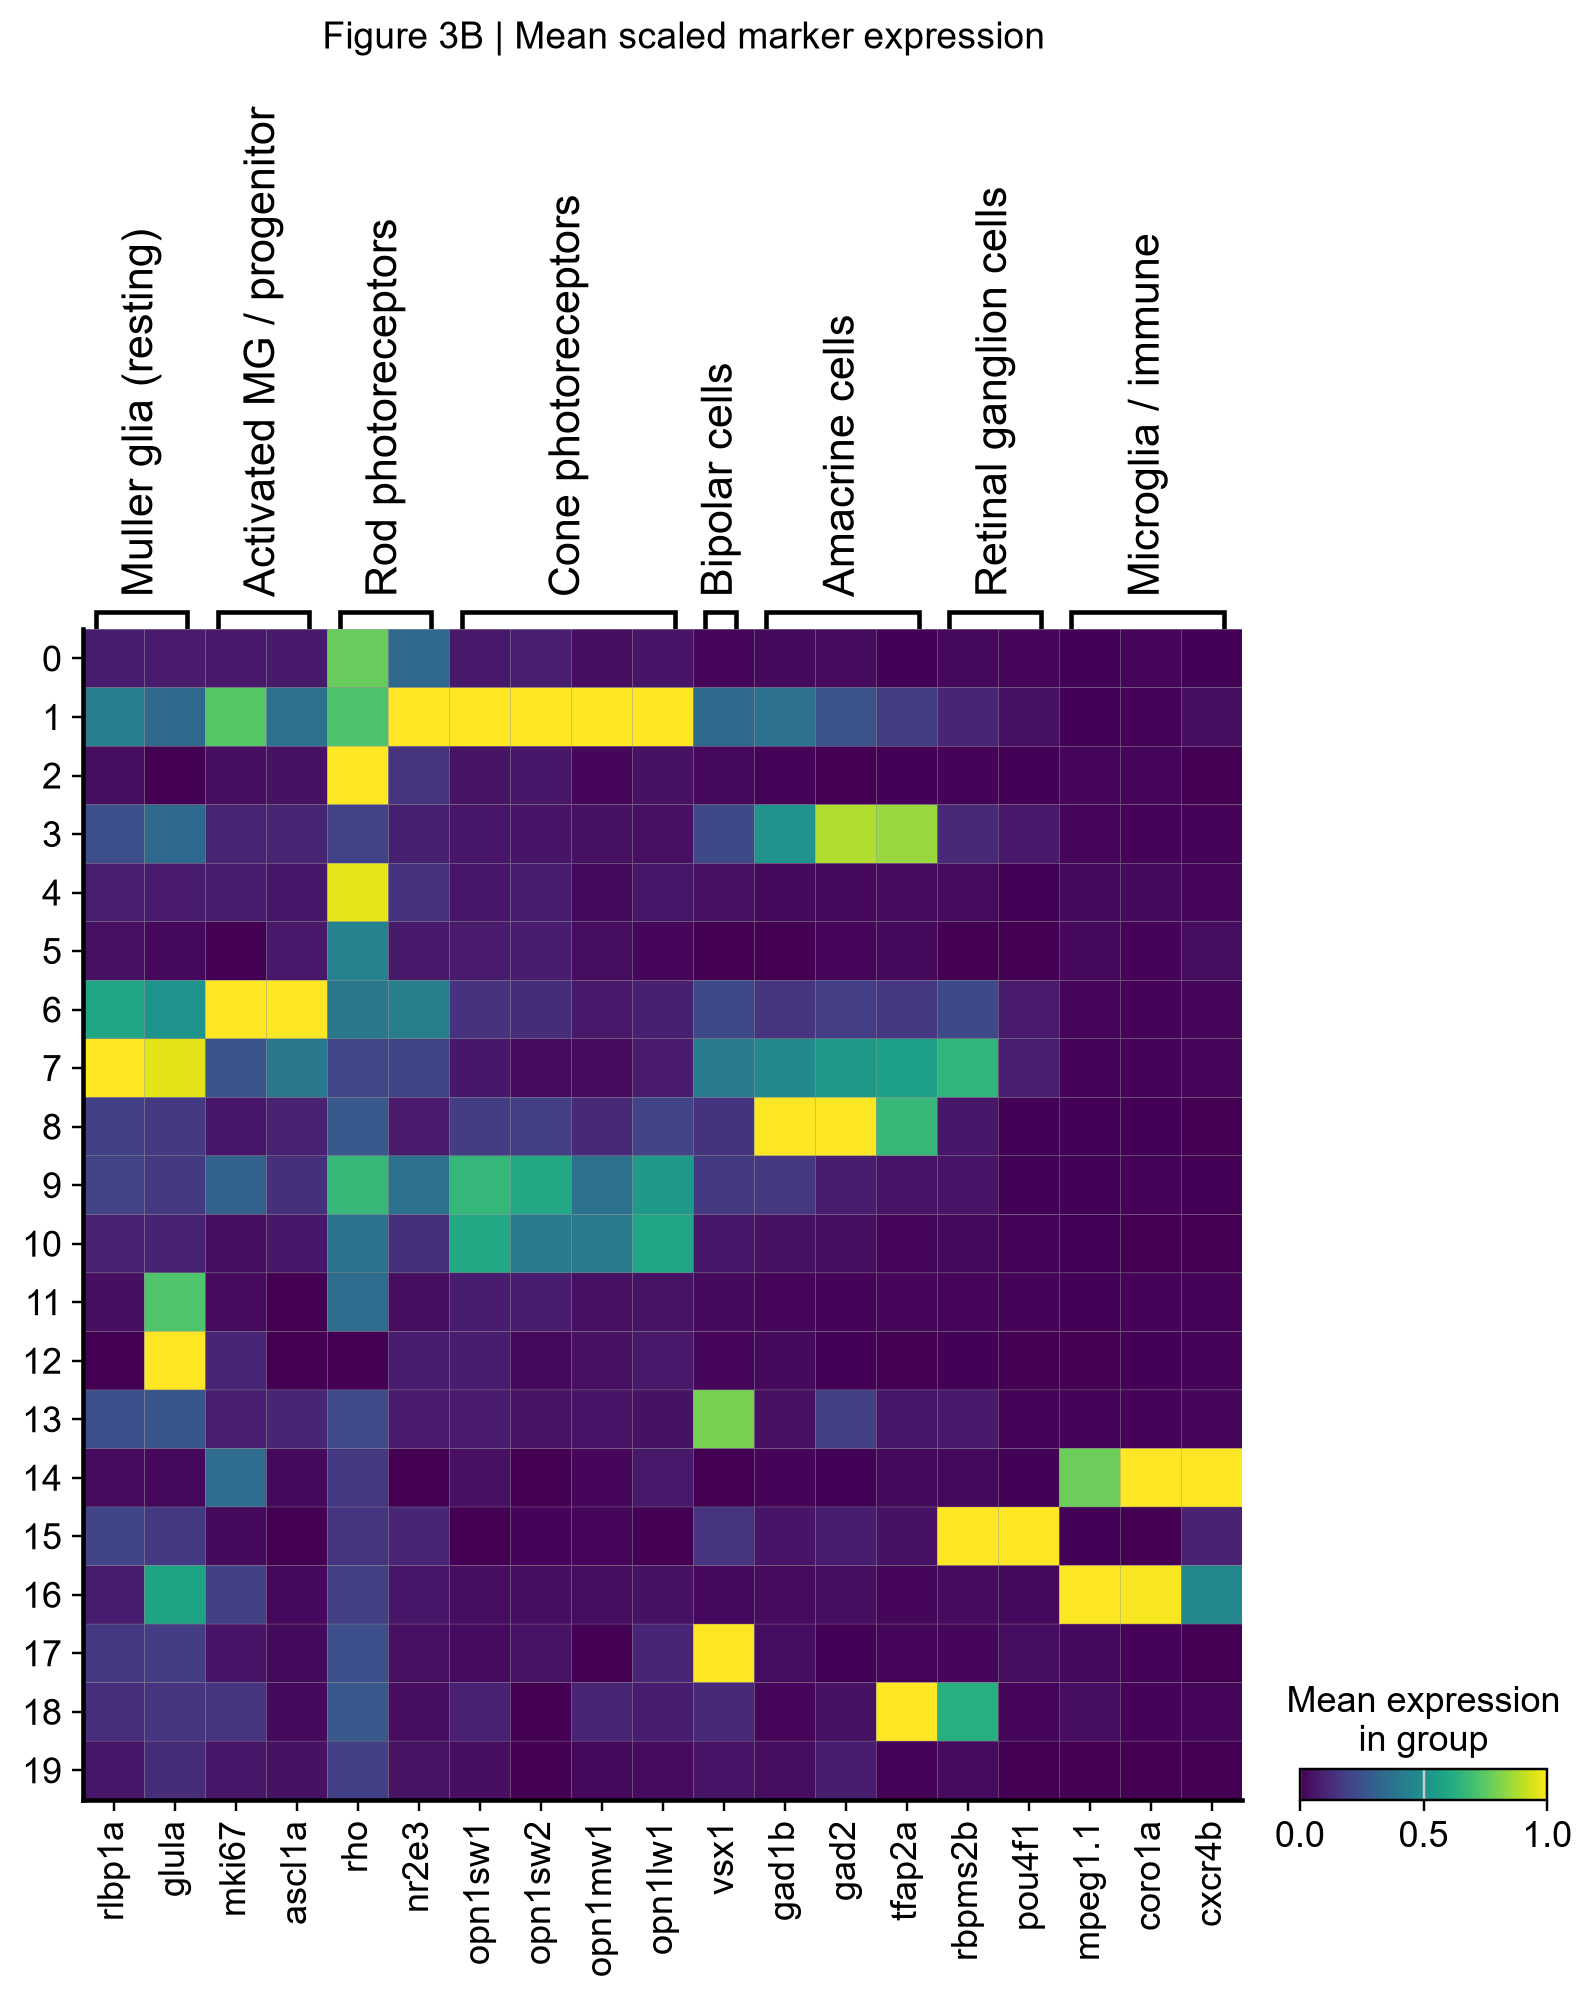

In [9]:
fig = plotting.figure_03_markers(adata, cfg.MARKERS_GUIDE)
fig = plotting.figure_03_heatmap(adata, cfg.MARKERS_GUIDE)


## 3. The annotation itself

**This cell is where your scientific judgement is recorded, and it is the one you
must be able to defend line by line.**

Fill in one entry per cluster. The template below is a *scaffold*: the cluster
numbers and the cell types are placeholders. Replace them using the tables above.
`build_annotation_table` refuses to run if any cluster is missing, if a rationale
is empty, or if confidence is not one of high/medium/low.

Expected from this dataset, based on the paper: rods dominate; cones, Müller glia,
bipolar, amacrine, horizontal cells, microglia, oligodendrocytes, erythrocytes,
pericytes and RPE are present in smaller numbers. **Retinal ganglion cells were
essentially not captured by Bise et al.** — if no cluster is `rbpms2b`-high here
either, that is a reproducible finding to report, not a failure to annotate.

In [10]:
import pandas as pd
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 250):
    print(annotation.top_markers_per_cluster(marker_df, n=10).to_string())
    print()
    print(suggestions.to_string())

   cluster                                                                                           top_10_genes
0        0                        pde6b, pde6a, map1ab, gnb1b, mbnl2, si:ch211-195b15.7, pdca, slkb, ndrg1a, sagb
1        1              si:dkey-14d8.22, si:ch211-98n17.5, hlx1, ap5m1, adhfe1, lzts2b, cry-dash, GPT, dph3, LSM2
2        2                      rho, pde6gb, ppdpfa, gngt1, rom1b, gnat1, rom1a, si:ch211-113d22.2, gnb1a, guca1a
3        3                                syt1a, stx1b, pclob, elavl3, tkta, gpm6aa, snap25a, grin1a, sv2a, pax6a
4        4                             mt-co2, mt-atp6, rho, mt-co1, mt-nd1, ppdpfa, mt-co3, gngt1, pde6gb, rom1b
5        5  hbba1-1, hbaa1, hbba1, si:ch211-5k11.8, creg1, rplp0, si:ch211-250g4.3, rpsa, si:ch211-103n10.5, mibp
6        6                  fabp7a, eef1a1l1, hmgn2, rplp0, rplp1, hsp90ab1, si:ch211-222l21.1, rpl8, rpl7a, rps2
7        7                             glula, nfasca, slc1a2b, cahz, gpm6aa, pleca, plek

In [11]:
print(adata.obs[cfg.LEIDEN_KEY].value_counts().sort_index().to_string())
print()
print(pd.read_csv(cfg.TABLES_DIR / "leiden_resolution_sweep.csv").to_string())

leiden_res_0.6
0     1881
1       15
2     2433
3     1274
4     1062
5      202
6     1471
7      336
8      712
9     1574
10    1040
11     760
12      87
13    1624
14     350
15      97
16     661
17     134
18      51
19     129

   resolution  n_clusters  smallest_cluster  largest_cluster  n_clusters_under_50_cells
0         0.2          12                51             3470                          0
1         0.4          13                51             3494                          0
2         0.6          20                15             2433                          1
3         0.8          24                15             2476                          1
4         1.0          26                51             2423                          0


In [12]:
print(adata.obs.groupby(cfg.LEIDEN_KEY, observed=True)[
    ["pct_counts_mt", "n_genes_by_counts", "total_counts"]].median().round(1).to_string())

                pct_counts_mt  n_genes_by_counts  total_counts
leiden_res_0.6                                                
0                         2.6              496.0         868.0
1                         5.5            12462.0      398264.0
2                         9.1              324.0         870.0
3                         3.7             1159.0        1906.0
4                        12.6              320.0         846.0
5                         4.7              286.0         662.0
6                         5.7              715.0        1239.0
7                         4.1             2548.0        5354.5
8                         6.0             1133.5        2030.5
9                         6.0              595.0        1012.5
10                        7.1             1421.5        3634.5
11                        3.8              409.0         813.5
12                        3.6             2162.0        6418.0
13                        4.8              730.5       

In [13]:
annotations = {
    "0":  {"cell_type": "Rods", "positive_markers": ["rp1l1b", "pde6gb", "aanat1"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "Phototransduction markers; low mito (2.6%); largest healthy rod cluster."},
    "1":  {"cell_type": "Unresolved", "positive_markers": [],
           "conflicting_markers": ["12462 genes/cell, 398k counts - ~100x dataset median"],
           "confidence": "low",
           "rationale": "15 cells with extreme counts and gene number; multiplets or gel-bead "
                        "aggregates, not a cell type. Excluded from downstream analysis. This is "
                        "the population the paper removed via scater doublet filtering."},
    "2":  {"cell_type": "Rods", "positive_markers": ["rho", "pde6gb", "guca1a", "rbp3"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "Canonical rod phototransduction programme; largest cluster."},
    "3":  {"cell_type": "Amacrine cells", "positive_markers": ["slc32a1", "pax6a", "elavl3", "snap25a"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "slc32a1 (VGAT) marks inhibitory neurons; pax6a and pan-neuronal snap25a/elavl3."},
    "4":  {"cell_type": "Rods (low quality)", "positive_markers": ["rho", "ppdpfa", "pde6gb"],
           "conflicting_markers": ["mt-co2 is top marker", "12.6% median mito", "320 genes/cell"],
           "confidence": "medium",
           "rationale": "Rod identity but mitochondrial-dominated and gene-poor; stressed/degraded "
                        "cells passing the 15% threshold. Kept but excluded from rod sub-analysis."},
    "5":  {"cell_type": "Erythrocytes", "positive_markers": ["hbba1", "hbaa1", "hbba2"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "Haemoglobin genes; residual blood from dissection."},
    "6":  {"cell_type": "Muller glia", "positive_markers": ["rlbp1a", "glula", "mdka", "crabp1a", "fabp7a"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "MG identity (rlbp1a, glula). Present at 5.5% of control cells, "
                        "so this is the main MG population, not an activated subset. mdka "
                        "and crabp1a are elevated and both appear in the paper's "
                        "EGFP-positive MG signature, but activation state is assessed in "
                        "step 06 from EGFP and proliferation markers, not asserted here."},
    "7":  {"cell_type": "Muller glia", "positive_markers": ["glula", "rlbp1a", "slc1a2b", "pleca"],
           "conflicting_markers": ["2548 genes/cell, above neighbours"],
           "confidence": "medium",
           "rationale": "Clear MG identity; high gene count may reflect RNA-rich glia or doublets."},
        "8":  {"cell_type": "Horizontal cells",
           "positive_markers": ["cx52.6", "rem1", "tnr", "pcdh8"],
           "conflicting_markers": ["cabp5a 0.77 - present but well below bipolar clusters"],
           "confidence": "medium",
           "rationale": "cx52.6 (1.010) and rem1 (1.342) are 5-10x higher than in any other "
                        "cluster; cx52.6 encodes a connexin specific to zebrafish horizontal cell "
                        "gap junctions. Neuronal adhesion genes (tnr, pcdh8, map1b) among the top "
                        "markers are consistent with an interneuron. cabp5a is present but far "
                        "below the bipolar clusters, excluding bipolar identity."},
    "9":  {"cell_type": "Cones", "positive_markers": ["gnat2", "pde6c", "arr3a", "gnb3b"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "Cone transducin/PDE/arrestin programme."},
    "10": {"cell_type": "Cones", "positive_markers": ["gnat2", "pde6c", "prph2a", "grk1b"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "Second cone cluster; subtype split examined in step 06."},
    "11": {"cell_type": "RPE", "positive_markers": ["tyrp1b", "pmela", "stra6", "rgrb"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "Melanogenesis (tyrp1b, pmela) and retinoid transport (stra6)."},
    "12": {"cell_type": "RPE", "positive_markers": ["rpe65a", "stra6", "rlbp1b"],
           "conflicting_markers": ["2162 genes/cell"], "confidence": "medium",
           "rationale": "rpe65a is definitive RPE; high gene count noted."},
    "13": {"cell_type": "Bipolar cells", "positive_markers": ["cabp5a", "grin1b", "lrit1a"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "cabp5a is a canonical bipolar marker; lrit1a is ON-bipolar associated."},
    "14": {"cell_type": "Unresolved", "positive_markers": [],
           "conflicting_markers": ["only cytoskeletal/housekeeping genes: actb1/2, pfn1, tmsb4x"],
           "confidence": "low",
           "rationale": "No identity marker; likely stressed cells or ambient-dominated droplets."},
    "15": {"cell_type": "Retinal ganglion cells", "positive_markers": ["rbpms2b", "gap43", "islr2", "elavl4"],
           "conflicting_markers": [], "confidence": "medium",
           "rationale": "rbpms2b with gap43 supports RGC identity. Note: Bise et al. report RGCs "
                        "were essentially not captured in their data; recovering 97 cells here is "
                        "a difference from the published result."},
    "16": {"cell_type": "Microglia", "positive_markers": ["apoc1", "ccl34b.1", "apoeb"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "apoc1 and the chemokine ccl34b.1 mark retinal macrophages."},
    "17": {"cell_type": "Bipolar cells", "positive_markers": ["trpm1b", "cadpsa", "syt5b"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "trpm1b is the ON-bipolar transduction channel."},
    "18": {"cell_type": "Pericytes", "positive_markers": ["col1a1b", "col1a2", "pdgfra"],
           "conflicting_markers": ["pdgfra is fibroblast-leaning"], "confidence": "low",
           "rationale": "Collagen-producing mesenchymal cells; pericyte or fibroblast, 51 cells "
                        "insufficient to distinguish."},
    "19": {"cell_type": "Oligodendrocytes", "positive_markers": ["mbpa", "plp1b", "cldnk"],
           "conflicting_markers": [], "confidence": "high",
           "rationale": "Myelin basic protein and proteolipid; optic nerve head contamination."},
}

In [14]:
cfg.CELL_TYPE_COLORS["Rods (low quality)"] = "#9ECAE1"

In [15]:
annotation_table = annotation.build_annotation_table(adata, annotations)
io_utils.save_table(annotation_table, "cluster_annotations.csv")
display(annotation_table)
adata = annotation.apply_annotations(adata, annotation_table)

Wrote tables\cluster_annotations.csv  (20 rows)


,cluster,n_cells,cell_type,positive_markers,conflicting_markers,confidence,rationale
0,0,1881,Rods,"rp1l1b, pde6gb, aanat1",,high,Phototransduction markers; low mito (2.6%); la...
1,1,15,Unresolved,,"12462 genes/cell, 398k counts - ~100x dataset ...",low,15 cells with extreme counts and gene number; ...
2,2,2433,Rods,"rho, pde6gb, guca1a, rbp3",,high,Canonical rod phototransduction programme; lar...
3,3,1274,Amacrine cells,"slc32a1, pax6a, elavl3, snap25a",,high,slc32a1 (VGAT) marks inhibitory neurons; pax6a...
4,4,1062,Rods (low quality),"rho, ppdpfa, pde6gb","mt-co2 is top marker, 12.6% median mito, 320 g...",medium,Rod identity but mitochondrial-dominated and g...
5,5,202,Erythrocytes,"hbba1, hbaa1, hbba2",,high,Haemoglobin genes; residual blood from dissect...
6,6,1471,Muller glia,"rlbp1a, glula, mdka, crabp1a, fabp7a",,high,"MG identity (rlbp1a, glula). Present at 5.5% o..."
7,7,336,Muller glia,"glula, rlbp1a, slc1a2b, pleca","2548 genes/cell, above neighbours",medium,Clear MG identity; high gene count may reflect...
8,8,712,Horizontal cells,"cx52.6, rem1, tnr, pcdh8",cabp5a 0.77 - present but well below bipolar c...,medium,cx52.6 (1.010) and rem1 (1.342) are 5-10x high...
9,9,1574,Cones,"gnat2, pde6c, arr3a, gnb3b",,high,Cone transducin/PDE/arrestin programme.


cell_type
Rods                      4314
Cones                     2614
Muller glia               1807
Bipolar cells             1758
Amacrine cells            1274
Rods (low quality)        1062
RPE                        847
Horizontal cells           712
Microglia                  661
Unresolved                 365
Erythrocytes               202
Oligodendrocytes           129
Retinal ganglion cells      97
Pericytes                   51


In [16]:
# Confidence audit: how many cells rest on weak calls?
audit = (
    annotation_table.groupby("confidence")["n_cells"].agg(["count", "sum"])
    .rename(columns={"count": "n_clusters", "sum": "n_cells"})
)
audit["pct_of_dataset"] = (100 * audit["n_cells"] / adata.n_obs).round(1)
display(audit)

low = annotation_table.loc[annotation_table["confidence"] == "low", "cluster"].tolist()
if low:
    print(f"Low-confidence clusters: {low}. Every conclusion that depends on these "
          "must be hedged in the Results section.")

,n_clusters,n_cells,pct_of_dataset
confidence,,,
high,12,13183,82.9
low,3,416,2.6
medium,5,2294,14.4


Low-confidence clusters: ['1', '14', '18']. Every conclusion that depends on these must be hedged in the Results section.


In [17]:
import pandas as pd
print((pd.crosstab(adata.obs["cell_type"], adata.obs["condition"], normalize="columns") * 100).round(1).to_string())

condition               ctrl   3dp   7dp  10dp
cell_type                                     
Muller glia              8.4  11.3  10.6  13.3
Rods                    11.9  34.1  26.7  29.2
Cones                   25.9  16.3  12.8  14.7
Bipolar cells           26.4  10.4   8.1   6.6
Amacrine cells           8.9   4.5  10.1   8.9
Horizontal cells         9.7   3.7   4.2   2.9
Retinal ganglion cells   0.4   0.1   0.9   0.9
Microglia                2.2   4.0   4.9   4.7
Oligodendrocytes         0.7   1.0   0.7   0.8
Erythrocytes             0.2   2.1   0.8   1.4
Pericytes                0.1   0.2   0.3   0.6
RPE                      4.1   2.9   6.0   7.3
Unresolved               0.6   4.0   1.4   2.4
Rods (low quality)       0.6   5.4  12.6   6.4



## Figure 3C — annotated UMAP

Saved figure_03_annotated_umap -> figures\figure_03_markers/ (png, pdf)


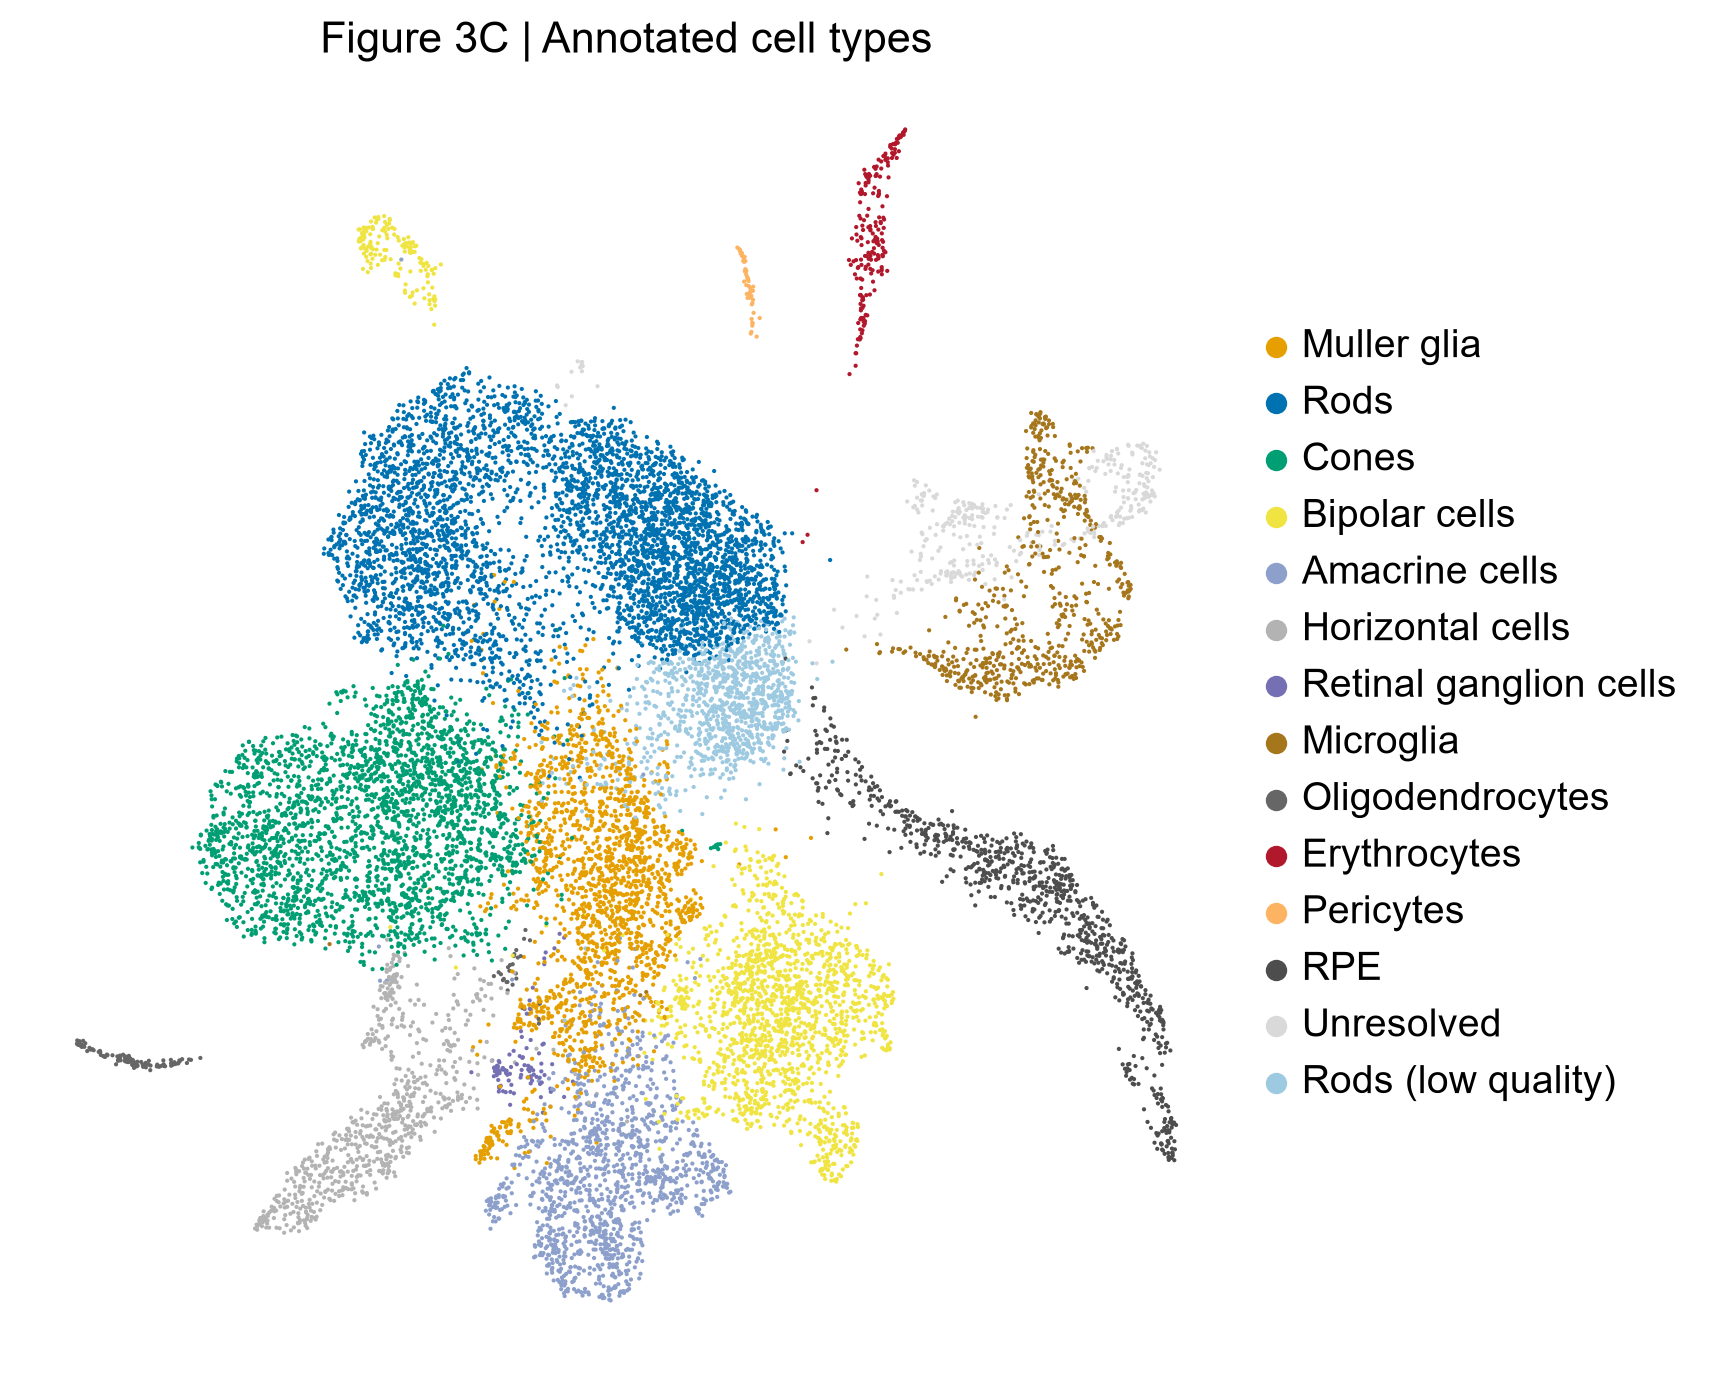

In [18]:
fig = plotting.figure_03_annotated_umap(adata)


## 4. Cell-type proportions (research question 2)

In [19]:
proportions = annotation.cell_type_proportions(adata)
io_utils.save_table(proportions, "cell_type_proportions.csv")

by_condition = annotation.proportions_by_condition(proportions)
display(by_condition.pivot(index="cell_type", columns="condition",
                           values="mean_percent").fillna(0))

Wrote tables\cell_type_proportions.csv  (110 rows)


condition,ctrl,3dp,7dp,10dp
cell_type,,,,
Muller glia,8.39,11.67,10.89,13.52
Rods,12.16,33.24,25.46,28.36
Cones,26.05,16.80,14.30,15.02
Bipolar cells,25.76,10.64,9.01,6.77
Amacrine cells,8.48,4.56,11.22,8.95
Horizontal cells,9.29,3.84,4.47,2.85
Retinal ganglion cells,0.62,0.12,1.02,0.86
Microglia,2.22,4.05,4.96,4.74
Oligodendrocytes,0.65,1.04,0.72,0.84


Saved figure_05_cell_type_proportions -> figures\figure_05_cell_proportions/ (png, pdf)

Cell-type proportions from scRNA-seq measure what was captured, not what was present in the tissue. Differential survival, dissociation efficiency, cell size and adhesion, capture efficiency and sequencing depth all shift these numbers. Bise et al. make exactly this point about their own data: the higher rod fraction in MNU-treated retinas is attributed to easier release of rods from a damaged outer nuclear layer, not to more rods being present. Any proportion change reported here carries the same caveat.


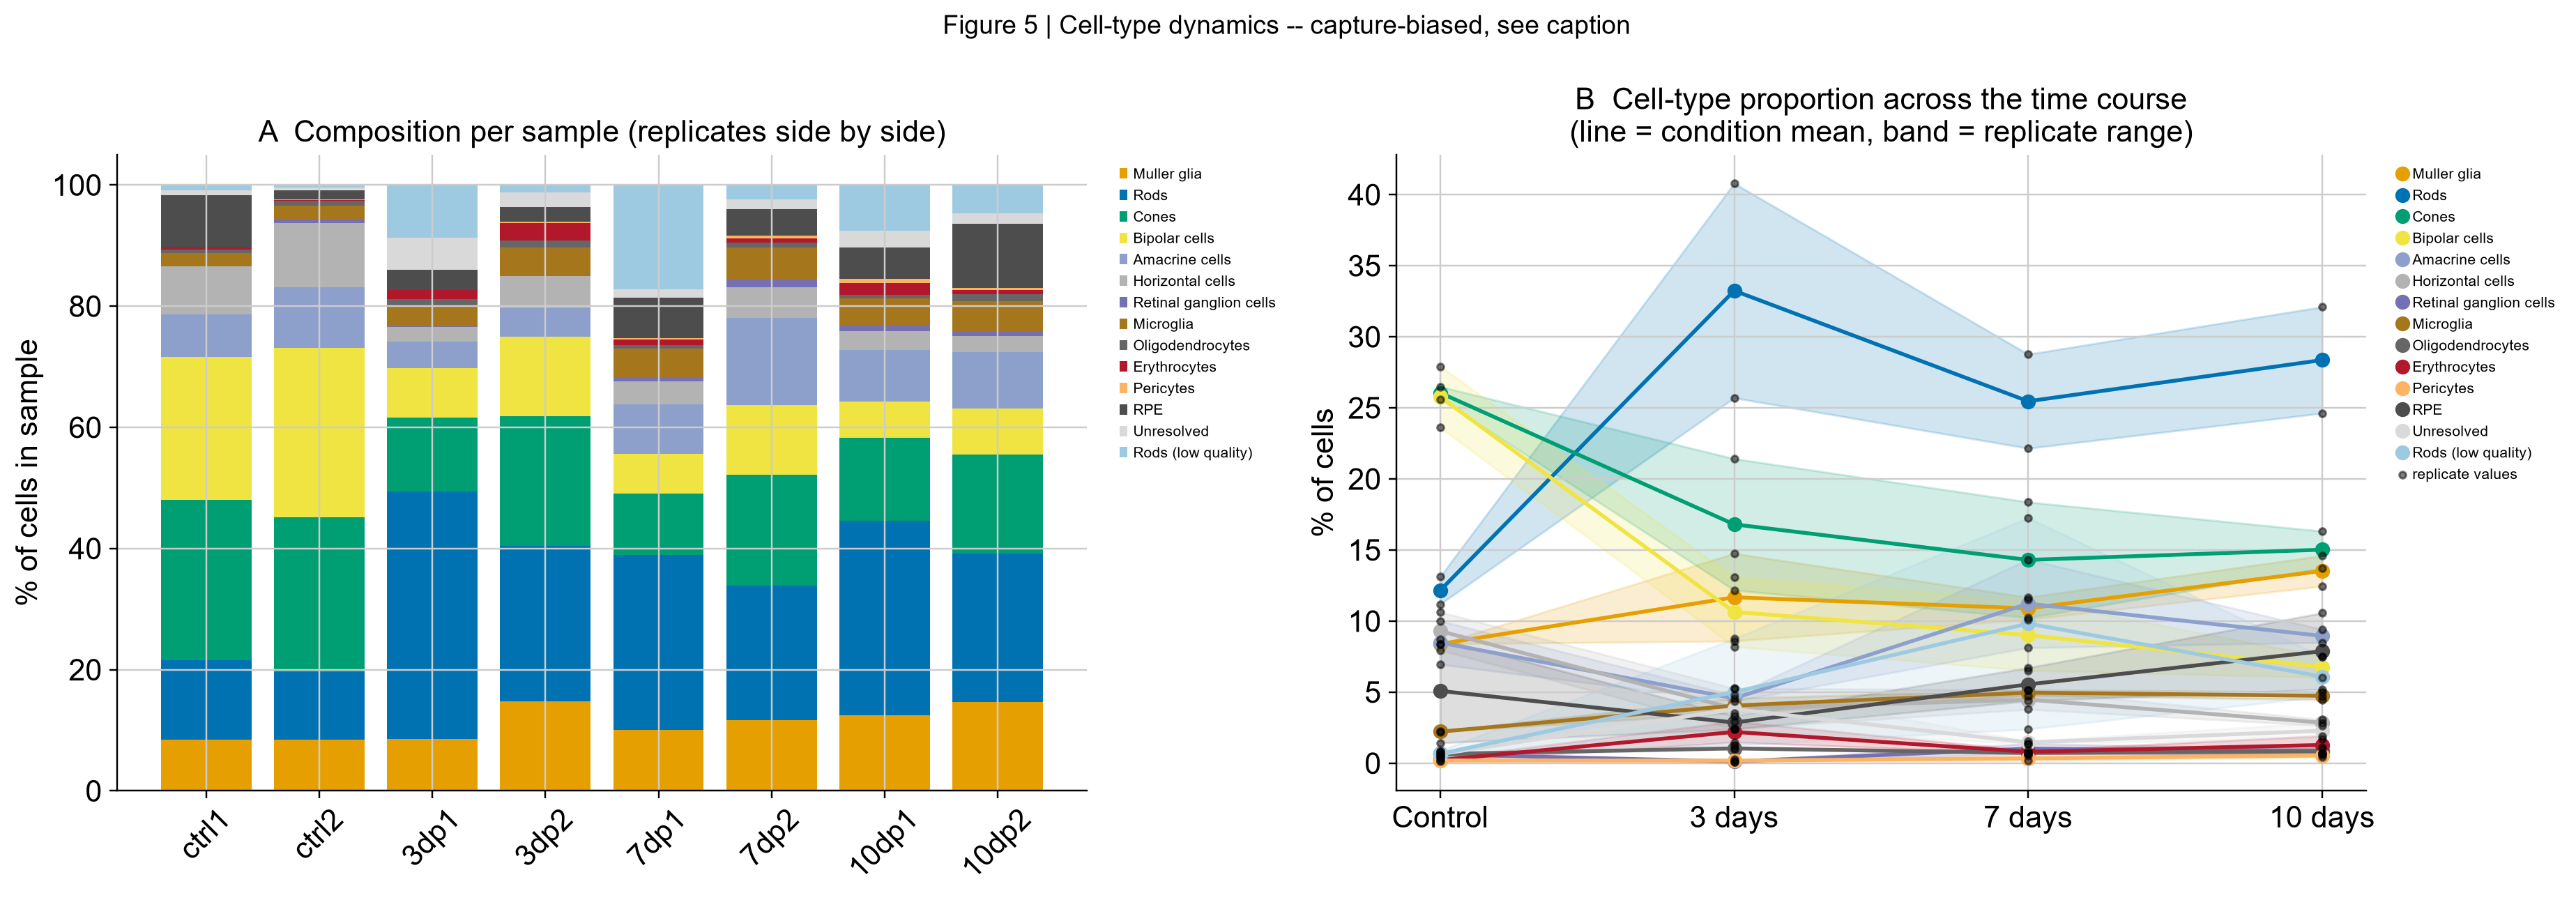

In [20]:
fig = plotting.figure_05_proportions(proportions, by_condition)
print("\n" + annotation.PROPORTION_CAVEAT)


### Interpretation — and the caveat that must travel with Figure 5

The caveat printed above is not boilerplate. Bise et al. explicitly attribute the
higher rod fraction in MNU-treated retinas to easier release of rods from a
damaged outer nuclear layer, i.e. a **capture effect**, not more rods. If the same
rise appears here, the honest statement is that rod *representation in the
library* increased, and that the data cannot distinguish this from a change in
tissue composition.

Note also the direction of the artefact: because proportions are compositional,
one cell type being over-captured mechanically depresses every other proportion.
A Müller glia percentage that falls after injury may reflect nothing but the rod
increase.

In [21]:
io_utils.save_checkpoint(adata, "annotated")

Saved checkpoint 'annotated' -> results\05_annotated.h5ad (201.2 MB)


WindowsPath('D:/retina/project1_zebrafish_retina/results/05_annotated.h5ad')

In [22]:
print(proportions[proportions["cell_type"].isin(["Rods (low quality)", "Rods", "Microglia"])]
      .pivot_table(index="cell_type", columns="sample", values="percent", observed=True)
      .round(2).to_string())

sample              ctrl1  ctrl2   3dp1   3dp2   7dp1   7dp2  10dp1  10dp2
cell_type                                                                 
Rods                13.13  11.19  40.79  25.70  28.77  22.15  32.10  24.62
Microglia            2.21   2.24   3.54   4.56   4.76   5.15   4.47   5.01
Rods (low quality)   0.88   0.44   8.76   1.25  17.25   2.40   7.50   4.68



### What to check before continuing

- [ ] Every cluster has an annotation entry with a real rationale.
- [ ] Müller glia are identified by identity markers, independently of EGFP.
- [ ] Ambiguous clusters are labelled `Unresolved`, not guessed.
- [ ] The RGC situation is recorded (found, or absent as in the paper).
- [ ] `tables/marker_genes.csv`, `cluster_annotations.csv`, `cell_type_proportions.csv` written.
- [ ] Figures 3 and 5 saved as PNG and PDF.